# Constant Velocity Scenario Comparison

This notebook combines the classical EKF experiment and trained neural workflows in one place. It compares `CEKF`, `DEKF`, `DKN`, and optional `GNN-RNN` checkpoints on the same constant-velocity distance/angle tracking scenario.

In [6]:
import importlib
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "utils").exists() else NOTEBOOK_DIR.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

torch.set_default_dtype(torch.float32)

import utils.ConstantVelocityScenario as constant_velocity_scenario_module
import utils.BaselineModels as baseline_models_module
importlib.reload(constant_velocity_scenario_module)
importlib.reload(baseline_models_module)

from utils.BaselineModels import GnnRnnLightning
from utils.ClassicDistributedKalman import (
    centralized_extended_kalman_filter,
    diffusion_extended_kalman_filter_parallel_edge,
)
from utils.ConstantVelocityScenario import (
    ConstantVelocityModel,
    DistanceAngleObservation,
    build_graph_data_for_dkn,
    create_distance_based_graph,
    generate_measurements,
    generate_node_positions,
    generate_trajectory,
    list_experiments,
    load_config,
    load_experiment_config,
    plot_graph,
    plot_tracking_results,
    plot_trajectory_and_nodes,
    seed_everything,
)
from utils.DistributedKalmanNet import GraphKalmanProcess


## Experiment Selection

List available experiments under `save_root` and pick which one to load.  The experiment's `experiment_config_<n>.json` drives the entire comparison.

In [7]:
base_config_path = REPO_ROOT / "configs" / "const_vel_scenario_configured.json"
base_config = load_config(base_config_path)
save_root = REPO_ROOT / base_config["save_root"]

experiments = list_experiments(save_root)
if not experiments:
    raise RuntimeError(f"No experiment_* folders found under {save_root}")

print("Available experiments:")
for i, exp in enumerate(experiments, start=1):
    tag = ""
    description = ""
    try:
        ecfg = load_experiment_config(exp)
    except FileNotFoundError:
        ecfg = None
    if ecfg is not None:
        exp_title = ecfg.get("title", "")
        title_str = f' — "{exp_title}"' if exp_title else ""
        tag = f"  (train_T={ecfg.get('train_time_steps','?')}, lr={ecfg.get('learning_rate','?')}){title_str}"
        description = ecfg.get("description", "")
    print(f"  [{i}] {exp.name}{tag}")
    if description:
        print(f"      {description}")


Available experiments:
  [1] experiment_1  (train_T=20, lr=0.001)
      dt mismatch initial poc
  [2] experiment_2  (train_T=20, lr=0.001)
      extereme model mismatch poc
  [3] experiment_3  (train_T=20, lr=0.001)
      comprehensive dt mismatch check
  [4] experiment_4  (train_T=20, lr=0.001)
      baseline study- gnn/DKN, with and w.o model mismatch in dt.


Loaded experiment: experiment_4
seed                                                                       42
state_dimension                                                             4
x0                                                             [0, 50, 0, 50]
time_delta                                                               0.08
process_noise_std                                                         1.0
p0_scale                                                                 10.0
measurement_noise_values                           [0.25, 0.5, 1.0, 2.0, 4.0]
use_dt_mismatch                                                          True
dt_mismatch_values                                                 [1.0, 1.5]
num_nodes                                                                  10
graph_seed                                                                 42
k_neighbors                                                                 5
node_positions              [[77

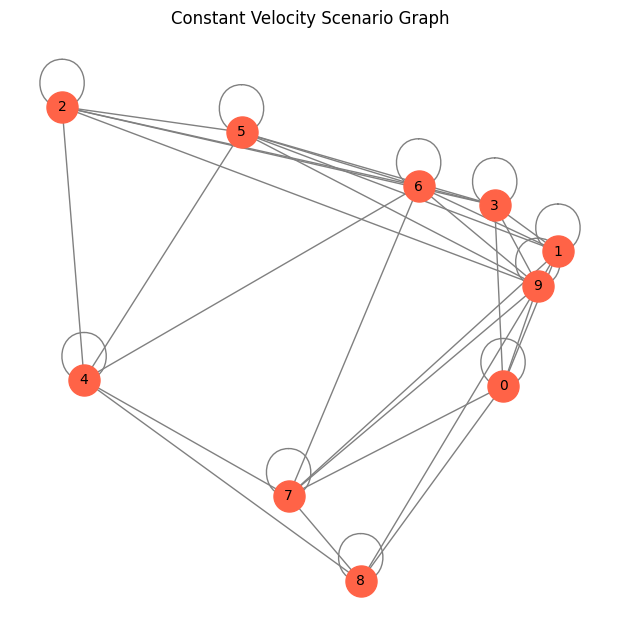

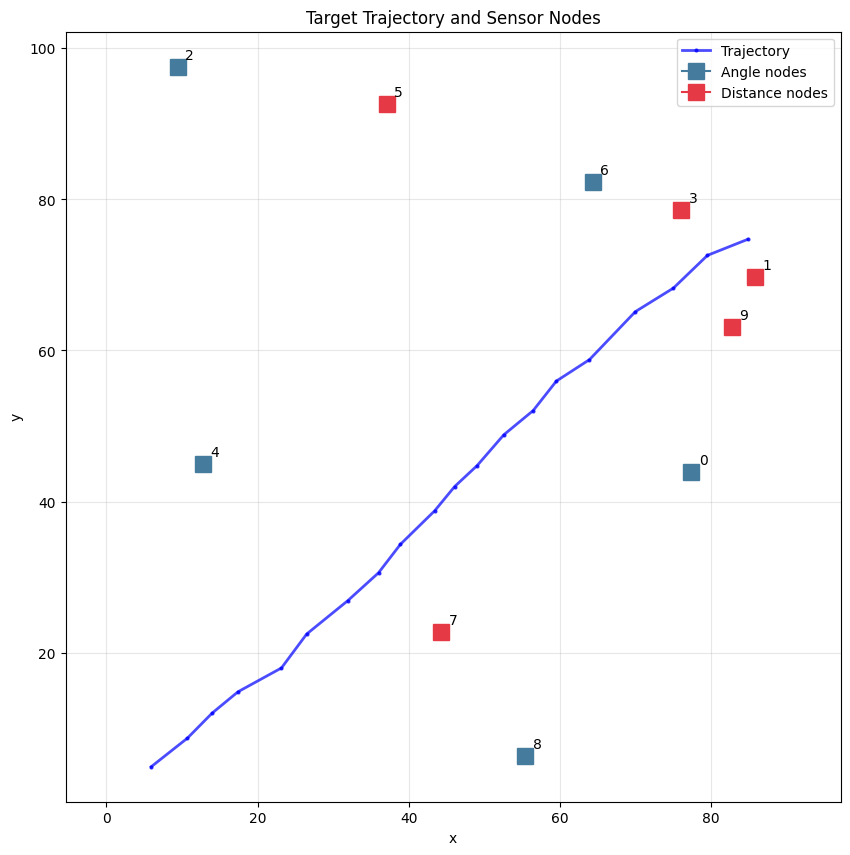

In [8]:
EXPERIMENT = 4 # ← set this to the number printed above, then run

experiment_dir = experiments[EXPERIMENT - 1]
config_val = load_experiment_config(experiment_dir)
print(f"Loaded experiment: {experiment_dir.name}")
print(pd.Series(config_val))

seed_everything(config_val["seed"])

num_nodes = config_val["num_nodes"]
use_dt_mismatch = config_val.get("use_dt_mismatch", False)
dt_mismatch_values = config_val.get("dt_mismatch_values", [1.0])
default_dkn_dt_ratio = min(dt_mismatch_values, key=lambda ratio: abs(float(ratio) - 1.0)) if use_dt_mismatch else None

state_dimension = config_val["state_dimension"]
x_init = np.array(config_val["x0"], dtype=float).reshape(state_dimension, 1)
p0 = np.eye(state_dimension) * config_val["p0_scale"]

train_time_steps = config_val["train_time_steps"]
test_time_steps = config_val.get("test_time_steps", train_time_steps)
num_time_steps = test_time_steps
num_trials = config_val["num_trials"]
process_noise_std = config_val["process_noise_std"]
time_delta = config_val["time_delta"]
measurement_noise_values = config_val["measurement_noise_values"]
node_positions = np.array(config_val["node_positions"], dtype=float)
f_system = ConstantVelocityModel(time_delta)
f_system_dkn = ConstantVelocityModel(time_delta * float(default_dkn_dt_ratio)) if use_dt_mismatch else f_system
h_system = DistanceAngleObservation(node_positions)
node_types = h_system.node_classification[:, 0].numpy().astype(int)

adjacency_matrix = create_distance_based_graph(
    node_positions,
    k_neighbors=config_val["k_neighbors"],
    seed=config_val["graph_seed"],
)
j_matrix = np.array(adjacency_matrix, dtype=float, copy=True)
np.fill_diagonal(j_matrix, 1.0)

# Match checkpoint names from DKN_training.py, including optional dt-mismatch runs.
def dkn_run_name(r_noise, dt_ratio=None):
    if use_dt_mismatch:
        ratio = default_dkn_dt_ratio if dt_ratio is None else dt_ratio
        return f"r={r_noise}_dtx{ratio}"
    return f"r={r_noise}"

def dkn_model_path(r_noise, dt_ratio=None, base_dir=experiment_dir):
    return base_dir / "DKN" / f"{dkn_run_name(r_noise, dt_ratio)}.pth"

def gnn_rnn_run_name(r_noise):
    return f"r={r_noise}"

def gnn_rnn_model_path(r_noise, base_dir=experiment_dir):
    return base_dir / "GNN_RNN" / f"{gnn_rnn_run_name(r_noise)}.pth"

def build_gnn_rnn_model(config):
    return GnnRnnLightning(
        input_dim=1,
        type_num=2,
        hidden_dim=config.get("gnn_rnn_hidden_dim", config["hidden_dim"]),
        output_dim=state_dimension,
        lr=config.get("gnn_rnn_learning_rate", config["learning_rate"]),
    )

def predict_gnn_rnn(model, graph_data, graph_h_system):
    node_types = graph_h_system.node_classification.to(dtype=torch.long)
    with torch.no_grad():
        return model(graph_data.x, node_types, graph_data.edge_index).cpu().numpy().mean(axis=0)

def clean_measurements_for_trajectory(graph_h_system, trajectory):
    clean = np.zeros((graph_h_system.num_nodes, 1, trajectory.shape[0]))
    for k in range(trajectory.shape[0]):
        x_k = trajectory[k].numpy() if isinstance(trajectory[k], torch.Tensor) else trajectory[k]
        clean[:, 0, k] = graph_h_system.func(x_k)[:, 0]
    if hasattr(graph_h_system, "wrap_measurements"):
        clean = graph_h_system.wrap_measurements(clean, sensor_axis=0)
    return clean

def measurement_snr_db(graph_h_system, trajectory, measurements, eps=1e-12):
    clean = clean_measurements_for_trajectory(graph_h_system, trajectory)
    noise = measurements - clean
    if hasattr(graph_h_system, "wrap_innovation"):
        noise = graph_h_system.wrap_innovation(noise, sensor_axis=0)
    signal_power = np.mean(clean ** 2)
    noise_power = np.mean(noise ** 2)
    return 10 * np.log10((signal_power + eps) / (noise_power + eps))

dkn_dir = experiment_dir / "DKN"
gnn_rnn_dir = experiment_dir / "GNN_RNN"
available_noise_values = [r for r in measurement_noise_values if dkn_model_path(r).exists()]
missing_noise_values = [r for r in measurement_noise_values if r not in available_noise_values]
if missing_noise_values:
    print(f"Warning: missing DKN checkpoints for r={missing_noise_values} in {dkn_dir} - skipping.")
if not available_noise_values:
    raise RuntimeError(f"No DKN checkpoints found in {dkn_dir}")

gnn_rnn_available_noise_values = [r for r in available_noise_values if gnn_rnn_model_path(r).exists()]
missing_gnn_rnn_noise_values = [r for r in available_noise_values if r not in gnn_rnn_available_noise_values]
if missing_gnn_rnn_noise_values:
    print(f"Warning: missing GNN-RNN checkpoints for r={missing_gnn_rnn_noise_values} in {gnn_rnn_dir} - omitting GNN-RNN for those rows.")
use_gnn_rnn = len(gnn_rnn_available_noise_values) > 0
measurement_noise_values = available_noise_values

plot_dir = experiment_dir / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

def get_trial_data(r_noise):
    trajectory = generate_trajectory(f_system, x_init, num_time_steps, process_noise_std)
    measurements = generate_measurements(h_system, trajectory, r_noise)
    return trajectory, measurements

print(f"\nTrain nodes:      {num_nodes}")
print(f"Train time steps: {train_time_steps}")
print(f"Test time steps:  {test_time_steps}")
if use_dt_mismatch:
    print(f"DKN checkpoint dt ratio for non-mismatch sections: {default_dkn_dt_ratio}")
plot_graph(adjacency_matrix, node_positions, title="Constant Velocity Scenario Graph")
plot_trajectory_and_nodes(node_positions, node_types, generate_trajectory(f_system, x_init, num_time_steps, process_noise_std))


## Single-Trial Comparison

Run one scenario and visualize the trajectory estimates from `CEKF`, `DEKF`, `DKN`, and optional `GNN-RNN` on exactly the same measurements.

In [4]:
r_demo = 0.25 if 0.25 in measurement_noise_values else measurement_noise_values[0]
trajectory, measurements = get_trial_data(r_demo)

x_hat_cekf = centralized_extended_kalman_filter(
    measurements=measurements,
    f_system=f_system,
    h_system=h_system,
    r_array=r_demo * np.ones(num_nodes),
    q=process_noise_std,
    p0=p0,
    x0=x_init,
    time_steps=num_time_steps,
    node_num=num_nodes,
)

x_hat_dekf = diffusion_extended_kalman_filter_parallel_edge(
    measurements=measurements,
    f_system=f_system,
    h_system=h_system,
    r_array=r_demo * np.ones(num_nodes),
    q=process_noise_std,
    p0=p0,
    x0=x_init,
    j_matrix=j_matrix,
    time_steps=num_time_steps,
    node_num=num_nodes,
)

graph_data = build_graph_data_for_dkn(adjacency_matrix, h_system, trajectory, measurements)
kalman_process = GraphKalmanProcess(
    f_system_dkn,
    signal_dim=state_dimension,
    edge_features_dim=1,
    node_kalman_dim=state_dimension**2,
    edge_kalman_dim=2,
    hidden_dim=config_val["hidden_dim"],
    lr=config_val["learning_rate"],
    r_array=r_demo,
    learn_edge_kalman=config_val["learn_edge_kalman"],
    x0_scale=x_init,
)
run_name_demo = dkn_run_name(r_demo)
example_model_path = dkn_model_path(r_demo)
kalman_process.load_state_dict(torch.load(example_model_path, map_location="cpu"))
kalman_process.eval()
with torch.no_grad():
    x_hat_dkn = kalman_process(graph_data).squeeze().cpu().numpy().mean(axis=1)

x_hat_gnn_rnn = None
if gnn_rnn_model_path(r_demo).exists():
    gnn_rnn_process = build_gnn_rnn_model(config_val)
    gnn_rnn_process.load_state_dict(torch.load(gnn_rnn_model_path(r_demo), map_location="cpu"))
    gnn_rnn_process.eval()
    x_hat_gnn_rnn = predict_gnn_rnn(gnn_rnn_process, graph_data, h_system)

demo_tracking_plot_path = plot_dir / f"{run_name_demo}_tracking_comparison.png"
plot_tracking_results(
    trajectory,
    x_hat_cekf,
    x_hat_dekf=x_hat_dekf,
    x_hat_dkn=x_hat_dkn,
    x_hat_gnn_rnn=x_hat_gnn_rnn,
    node_positions=node_positions,
    node_types=node_types,
    save_path=demo_tracking_plot_path,
)


/home/kfir-goldring/University/distributedKNET/utils/ConstantVelocityScenario.py:456: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  trajectory_tensor = torch.tensor(trajectory, dtype=torch.float32)


TypeError: plot_tracking_results() got an unexpected keyword argument 'x_hat_gnn_rnn'

## Monte Carlo Study

For each measurement noise level, evaluate seven series on the same randomly generated trajectories: `GNN-RNN` once because it has no explicit dynamics model, plus `CEKF`, `DEKF`, and `DKN` each with no-mismatch and mismatched `dt` dynamics. The results include both noise-vs-error and empirical SNR-vs-error plots.


In [9]:
if not use_dt_mismatch:
    raise RuntimeError("Monte Carlo mismatch comparison requires an experiment with use_dt_mismatch=true.")

def format_dt_ratio(ratio):
    ratio_float = float(ratio)
    if np.isclose(ratio_float, round(ratio_float)):
        return f"{ratio_float:.1f}"
    return f"{ratio_float:g}"

MONTE_CARLO_NO_MISMATCH_RATIO = min(dt_mismatch_values, key=lambda ratio: abs(float(ratio) - 1.0))
if not np.isclose(float(MONTE_CARLO_NO_MISMATCH_RATIO), 1.0):
    raise RuntimeError(f"Need a no-mismatch dt ratio near 1.0; got {dt_mismatch_values}.")
monte_carlo_mismatch_candidates = [ratio for ratio in dt_mismatch_values if not np.isclose(float(ratio), float(MONTE_CARLO_NO_MISMATCH_RATIO))]
if not monte_carlo_mismatch_candidates:
    raise RuntimeError(f"Need at least one dt mismatch ratio besides {MONTE_CARLO_NO_MISMATCH_RATIO}; got {dt_mismatch_values}.")
MONTE_CARLO_MISMATCH_RATIO = max(monte_carlo_mismatch_candidates, key=lambda ratio: abs(float(ratio) - 1.0))
monte_carlo_dt_ratios = [MONTE_CARLO_NO_MISMATCH_RATIO, MONTE_CARLO_MISMATCH_RATIO]

monte_carlo_labels = {
    model_name: {ratio: f"{model_name} dt x{format_dt_ratio(ratio)}" for ratio in monte_carlo_dt_ratios}
    for model_name in ["CEKF", "DEKF", "DKN"]
}
monte_carlo_series = [
    monte_carlo_labels["CEKF"][MONTE_CARLO_NO_MISMATCH_RATIO],
    monte_carlo_labels["CEKF"][MONTE_CARLO_MISMATCH_RATIO],
    monte_carlo_labels["DEKF"][MONTE_CARLO_NO_MISMATCH_RATIO],
    monte_carlo_labels["DEKF"][MONTE_CARLO_MISMATCH_RATIO],
    monte_carlo_labels["DKN"][MONTE_CARLO_NO_MISMATCH_RATIO],
    monte_carlo_labels["DKN"][MONTE_CARLO_MISMATCH_RATIO],
    "GNN-RNN",
]

print(f"Monte Carlo dt ratios: no mismatch={format_dt_ratio(MONTE_CARLO_NO_MISMATCH_RATIO)}, mismatch={format_dt_ratio(MONTE_CARLO_MISMATCH_RATIO)}")

def load_state_dict_checked(model, path):
    state_dict = torch.load(path, map_location="cpu")
    nonfinite_count = sum(
        (~torch.isfinite(value)).sum().item()
        for value in state_dict.values()
        if torch.is_tensor(value) and value.is_floating_point()
    )
    if nonfinite_count:
        print(f"Warning: {path.name} contains {nonfinite_count} non-finite parameters; its results may be NaN.")
    model.load_state_dict(state_dict)
    model.eval()
    return model

def position_error_from_state_sequence(trajectory, estimate):
    x_true = trajectory[:, 0, 0].numpy()
    y_true = trajectory[:, 2, 0].numpy()
    return np.sqrt((x_true - estimate[:, 0]) ** 2 + (y_true - estimate[:, 2]) ** 2).mean()

def position_error_from_dekf(trajectory, estimate):
    x_true = trajectory[:, 0, 0].numpy()
    y_true = trajectory[:, 2, 0].numpy()
    x_est = estimate[:, :, 0, 0].mean(axis=1)
    y_est = estimate[:, :, 2, 0].mean(axis=1)
    return np.sqrt((x_true - x_est) ** 2 + (y_true - y_est) ** 2).mean()

avg_snr_db = []
avg_errors = {label: [] for label in monte_carlo_series}

for r_noise in measurement_noise_values:
    r_array = r_noise * np.ones(num_nodes)

    dkn_processes = {}
    for dt_ratio in monte_carlo_dt_ratios:
        model_path = dkn_model_path(r_noise, dt_ratio)
        if not model_path.exists():
            raise FileNotFoundError(f"Missing DKN checkpoint for Monte Carlo comparison: {model_path}")
        f_model_ratio = ConstantVelocityModel(time_delta * float(dt_ratio))
        kalman_process = GraphKalmanProcess(
            f_model_ratio,
            signal_dim=state_dimension,
            edge_features_dim=1,
            node_kalman_dim=state_dimension**2,
            edge_kalman_dim=2,
            hidden_dim=config_val["hidden_dim"],
            lr=config_val["learning_rate"],
            r_array=r_noise,
            learn_edge_kalman=config_val["learn_edge_kalman"],
            x0_scale=x_init,
        )
        dkn_processes[dt_ratio] = load_state_dict_checked(kalman_process, model_path)

    gnn_rnn_process = None
    if gnn_rnn_model_path(r_noise).exists():
        gnn_rnn_process = build_gnn_rnn_model(config_val)
        gnn_rnn_process = load_state_dict_checked(gnn_rnn_process, gnn_rnn_model_path(r_noise))
    else:
        print(f"No GNN-RNN checkpoint found for r={r_noise}; GNN-RNN result will be NaN.")

    trial_snr_db = []
    trial_errors = {label: [] for label in monte_carlo_series}

    for _ in tqdm(range(num_trials), desc=f"r={r_noise}"):
        trajectory, measurements = get_trial_data(r_noise)
        trial_snr_db.append(measurement_snr_db(h_system, trajectory, measurements))
        graph_data = build_graph_data_for_dkn(adjacency_matrix, h_system, trajectory, measurements)

        for dt_ratio in monte_carlo_dt_ratios:
            f_model_ratio = ConstantVelocityModel(time_delta * float(dt_ratio))
            x_hat_cekf = centralized_extended_kalman_filter(
                measurements=measurements,
                f_system=f_model_ratio,
                h_system=h_system,
                r_array=r_array,
                q=process_noise_std,
                p0=p0,
                x0=x_init,
                time_steps=num_time_steps,
                node_num=num_nodes,
            )
            x_hat_dekf = diffusion_extended_kalman_filter_parallel_edge(
                measurements=measurements,
                f_system=f_model_ratio,
                h_system=h_system,
                r_array=r_array,
                q=process_noise_std,
                p0=p0,
                x0=x_init,
                j_matrix=j_matrix,
                time_steps=num_time_steps,
                node_num=num_nodes,
            )
            with torch.no_grad():
                x_hat_dkn = dkn_processes[dt_ratio](graph_data).squeeze().cpu().numpy().mean(axis=1)

            trial_errors[monte_carlo_labels["CEKF"][dt_ratio]].append(position_error_from_state_sequence(trajectory, x_hat_cekf[:, :, 0]))
            trial_errors[monte_carlo_labels["DEKF"][dt_ratio]].append(position_error_from_dekf(trajectory, x_hat_dekf))
            trial_errors[monte_carlo_labels["DKN"][dt_ratio]].append(position_error_from_state_sequence(trajectory, x_hat_dkn))

        if gnn_rnn_process is not None:
            x_hat_gnn_rnn = predict_gnn_rnn(gnn_rnn_process, graph_data, h_system)
            trial_errors["GNN-RNN"].append(position_error_from_state_sequence(trajectory, x_hat_gnn_rnn))

    avg_snr_db.append(np.mean(trial_snr_db))
    for label in monte_carlo_series:
        avg_errors[label].append(np.mean(trial_errors[label]) if trial_errors[label] else np.nan)

results_df = pd.DataFrame(
    {
        "measurement_noise": measurement_noise_values,
        "snr_db": avg_snr_db,
        **avg_errors,
    }
)
results_df





Monte Carlo dt ratios: no mismatch=1.0, mismatch=1.5


r=4.0: 100%|██████████| 50/50 [00:06<00:00,  7.15it/s]


,measurement_noise,snr_db,CEKF dt x1.0,CEKF dt x1.5,DEKF dt x1.0,DEKF dt x1.5,DKN dt x1.0,DKN dt x1.5,GNN-RNN
0,0.25,44.032474,0.246647,0.251449,0.281647,0.306485,NaN,0.378755,2.101004
1,0.50,38.010839,0.462019,0.475368,0.503493,0.543123,0.477127,0.549401,1.491762
2,1.00,32.131238,0.809538,0.884730,0.828982,0.975923,0.804505,0.829233,1.603378
3,2.00,26.620765,1.401936,1.752124,1.446546,1.949219,1.327355,1.366083,1.736996
4,4.00,22.115393,2.238435,3.312437,2.264455,3.733081,1.964732,1.998025,2.506380


In [ ]:
summary_plot_path = plot_dir / f"const_vel_scenario_summary_mismatch_trials={num_trials}_T={num_time_steps}.png"
monte_carlo_plot_styles = {
    monte_carlo_labels["CEKF"][MONTE_CARLO_NO_MISMATCH_RATIO]: "o-",
    monte_carlo_labels["CEKF"][MONTE_CARLO_MISMATCH_RATIO]: "o--",
    monte_carlo_labels["DEKF"][MONTE_CARLO_NO_MISMATCH_RATIO]: "s-",
    monte_carlo_labels["DEKF"][MONTE_CARLO_MISMATCH_RATIO]: "s--",
    monte_carlo_labels["DKN"][MONTE_CARLO_NO_MISMATCH_RATIO]: "^-",
    monte_carlo_labels["DKN"][MONTE_CARLO_MISMATCH_RATIO]: "^--",
    "GNN-RNN": "d:",
}

# Plot error in dB (10*log10) against inverse measurement-noise variance 1/r^2, also in dB.
def error_to_db(error_values):
    return 10.0 * np.log10(error_values)

inv_r_squared_db = 10.0 * np.log10(1.0 / (np.asarray(measurement_noise_values, dtype=float) ** 2))

plt.figure(figsize=(11, 7))
plotted_labels = []
for label, style in monte_carlo_plot_styles.items():
    if label in results_df.columns and results_df[label].notna().any():
        plt.plot(inv_r_squared_db, error_to_db(results_df[label]), style, linewidth=2, markersize=7, label=label)
        plotted_labels.append(label)
print(f"Plotted {len(plotted_labels)} Monte Carlo (1/r^2)-vs-error lines: {plotted_labels}")
plt.xlabel(r"$1/r^2$ (dB)")
plt.ylabel("Average Position Error (dB)")
plt.title(f"Constant Velocity Scenario Comparison ({num_trials} trials, q={process_noise_std}, T={num_time_steps}, learn_edge_kalman={config_val['learn_edge_kalman']})")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.savefig(summary_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved summary plot: {summary_plot_path}")
plt.show()

snr_summary_plot_path = plot_dir / f"const_vel_scenario_snr_vs_error_mismatch_trials={num_trials}_T={num_time_steps}.png"
snr_results_df = results_df.sort_values("snr_db")
plt.figure(figsize=(11, 7))
plotted_snr_labels = []
for label, style in monte_carlo_plot_styles.items():
    if label in snr_results_df.columns and snr_results_df[label].notna().any():
        plt.plot(snr_results_df["snr_db"], error_to_db(snr_results_df[label]), style, linewidth=2, markersize=7, label=label)
        plotted_snr_labels.append(label)
print(f"Plotted {len(plotted_snr_labels)} Monte Carlo SNR-vs-error lines: {plotted_snr_labels}")
plt.xlabel("Empirical Measurement SNR (dB)")
plt.ylabel("Average Position Error (dB)")
plt.title(f"SNR vs Error ({num_trials} trials, q={process_noise_std}, T={num_time_steps})")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.savefig(snr_summary_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved SNR summary plot: {snr_summary_plot_path}")
plt.show()


## Node-Count Generalization

Evaluate trained DKN and optional GNN-RNN checkpoints against fresh constant-velocity scenarios with different numbers of test nodes. Set `TEST_NUM_NODES_VALUES` below to choose the sweep; both neural models are node-count-agnostic as long as the sensor measurement types are rebuilt for each graph.


nodes=40: 100%|██████████| 50/50 [00:17<00:00,  2.81it/s]


Saved: /home/kfir-goldring/University/distributedKNET/models/kfir/experiment_3/plots/node_count_generalization_r=1.0_dtx1_trainN=10_trials=50.png


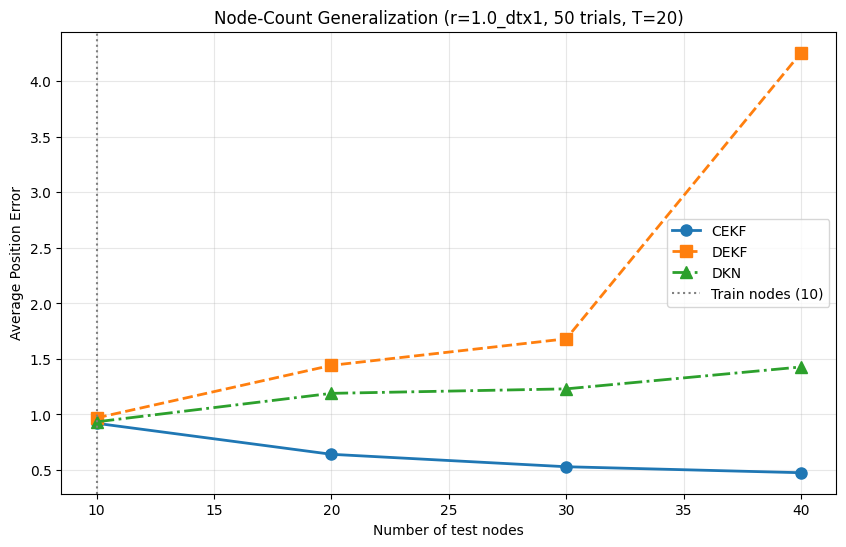

,test_num_nodes,CEKF,DEKF,DKN
0,10,0.920623,0.968964,0.933682
1,20,0.641400,1.442170,1.190216
2,30,0.529360,1.681364,1.230637
3,40,0.475465,4.257578,1.427937


In [ ]:
TEST_NUM_NODES_VALUES = [10, 20, 30, 40]  # ← node counts to evaluate against

train_num_nodes = num_nodes
NODE_COUNT_R_EVAL = measurement_noise_values[0]
NODE_COUNT_DKN_DT_RATIO = default_dkn_dt_ratio if use_dt_mismatch else None
node_count_run_name = dkn_run_name(NODE_COUNT_R_EVAL, NODE_COUNT_DKN_DT_RATIO)
node_count_model_path = dkn_model_path(NODE_COUNT_R_EVAL, NODE_COUNT_DKN_DT_RATIO)
#node_count_model_path ="/home/kfir-goldring/University/distributedKNET/models/kfir/experiment_3/DKN/r=1.0_dtx1.pth"
if not node_count_model_path.exists():
    raise FileNotFoundError(f"Missing DKN checkpoint for node-count sweep: {node_count_model_path}")

f_data_nodes = ConstantVelocityModel(time_delta)
f_model_nodes = ConstantVelocityModel(time_delta * float(NODE_COUNT_DKN_DT_RATIO)) if use_dt_mismatch else f_data_nodes

node_count_kalman_process = GraphKalmanProcess(
    f_model_nodes,
    signal_dim=state_dimension,
    edge_features_dim=1,
    node_kalman_dim=state_dimension**2,
    edge_kalman_dim=2,
    hidden_dim=config_val["hidden_dim"],
    lr=config_val["learning_rate"],
    # Scalar noise keeps the loaded DKN usable for any test graph size.
    r_array=NODE_COUNT_R_EVAL,
    learn_edge_kalman=config_val["learn_edge_kalman"],
    x0_scale=x_init,
)
node_count_kalman_process.load_state_dict(torch.load(node_count_model_path, map_location="cpu"))
node_count_kalman_process.eval()

node_count_gnn_rnn_process = None
node_count_gnn_rnn_path = gnn_rnn_model_path(NODE_COUNT_R_EVAL)
if node_count_gnn_rnn_path.exists():
    node_count_gnn_rnn_process = build_gnn_rnn_model(config_val)
    node_count_gnn_rnn_process.load_state_dict(torch.load(node_count_gnn_rnn_path, map_location="cpu"))
    node_count_gnn_rnn_process.eval()
else:
    print(f"No GNN-RNN checkpoint found at {node_count_gnn_rnn_path}; omitting GNN-RNN from node-count sweep.")

node_count_errors_cekf = []
node_count_errors_dekf = []
node_count_errors_dkn = []
node_count_errors_gnn_rnn = []

for test_num_nodes in TEST_NUM_NODES_VALUES:
    # Rebuild all graph-dependent objects for this test node count.
    test_node_positions = generate_node_positions(test_num_nodes, seed=config_val["graph_seed"])
    test_h_system = DistanceAngleObservation(test_node_positions)
    test_adjacency_matrix = create_distance_based_graph(
        test_node_positions,
        k_neighbors=config_val["k_neighbors"],
        seed=config_val["graph_seed"],
    )
    test_j_matrix = np.array(test_adjacency_matrix, dtype=float, copy=True)
    np.fill_diagonal(test_j_matrix, 1.0)
    test_r_array = NODE_COUNT_R_EVAL * np.ones(test_num_nodes)

    # Paired trials keep CEKF, DEKF, and DKN on identical measurements.
    paired_trials = []
    for _ in range(num_trials):
        traj = generate_trajectory(f_data_nodes, x_init, num_time_steps, process_noise_std)
        meas = generate_measurements(test_h_system, traj, NODE_COUNT_R_EVAL)
        paired_trials.append((traj, meas))

    trial_errors_cekf = []
    trial_errors_dekf = []
    trial_errors_dkn = []
    trial_errors_gnn_rnn = []

    for trajectory, measurements in tqdm(paired_trials, desc=f"nodes={test_num_nodes}"):
        x_hat_cekf_n = centralized_extended_kalman_filter(
            measurements=measurements,
            f_system=f_model_nodes,
            h_system=test_h_system,
            r_array=test_r_array,
            q=process_noise_std,
            p0=p0,
            x0=x_init,
            time_steps=num_time_steps,
            node_num=test_num_nodes,
        )
        x_hat_dekf_n = diffusion_extended_kalman_filter_parallel_edge(
            measurements=measurements,
            f_system=f_model_nodes,
            h_system=test_h_system,
            r_array=test_r_array,
            q=process_noise_std,
            p0=p0,
            x0=x_init,
            j_matrix=test_j_matrix,
            time_steps=num_time_steps,
            node_num=test_num_nodes,
        )

        graph_data = build_graph_data_for_dkn(test_adjacency_matrix, test_h_system, trajectory, measurements)
        with torch.no_grad():
            x_hat_dkn_n = node_count_kalman_process(graph_data).squeeze().cpu().numpy().mean(axis=1)
        x_hat_gnn_rnn_n = predict_gnn_rnn(node_count_gnn_rnn_process, graph_data, test_h_system) if node_count_gnn_rnn_process is not None else None

        x_true = trajectory[:, 0, 0].numpy()
        y_true = trajectory[:, 2, 0].numpy()

        x_cekf = x_hat_cekf_n[:, 0, 0]
        y_cekf = x_hat_cekf_n[:, 2, 0]
        trial_errors_cekf.append(np.sqrt((x_true - x_cekf) ** 2 + (y_true - y_cekf) ** 2).mean())

        x_dekf = x_hat_dekf_n[:, :, 0, 0].mean(axis=1)
        y_dekf = x_hat_dekf_n[:, :, 2, 0].mean(axis=1)
        trial_errors_dekf.append(np.sqrt((x_true - x_dekf) ** 2 + (y_true - y_dekf) ** 2).mean())

        trial_errors_dkn.append(np.sqrt((x_true - x_hat_dkn_n[:, 0]) ** 2 + (y_true - x_hat_dkn_n[:, 2]) ** 2).mean())
        if x_hat_gnn_rnn_n is not None:
            trial_errors_gnn_rnn.append(np.sqrt((x_true - x_hat_gnn_rnn_n[:, 0]) ** 2 + (y_true - x_hat_gnn_rnn_n[:, 2]) ** 2).mean())

    node_count_errors_cekf.append(np.mean(trial_errors_cekf))
    node_count_errors_dekf.append(np.mean(trial_errors_dekf))
    node_count_errors_dkn.append(np.mean(trial_errors_dkn))
    node_count_errors_gnn_rnn.append(np.mean(trial_errors_gnn_rnn) if trial_errors_gnn_rnn else np.nan)

node_count_results_df = pd.DataFrame({
    "test_num_nodes": TEST_NUM_NODES_VALUES,
    "CEKF": node_count_errors_cekf,
    "DEKF": node_count_errors_dekf,
    "DKN": node_count_errors_dkn,
    "GNN-RNN": node_count_errors_gnn_rnn,
})

node_count_summary_path = plot_dir / f"node_count_generalization_{node_count_run_name}_trainN={train_num_nodes}_trials={num_trials}.png"
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(node_count_results_df["test_num_nodes"], node_count_results_df["CEKF"], "o-", linewidth=2, markersize=8, label="CEKF")
ax.plot(node_count_results_df["test_num_nodes"], node_count_results_df["DEKF"], "s--", linewidth=2, markersize=8, label="DEKF")
ax.plot(node_count_results_df["test_num_nodes"], node_count_results_df["DKN"], "^-.", linewidth=2, markersize=8, label="DKN")
if node_count_results_df["GNN-RNN"].notna().any():
    ax.plot(node_count_results_df["test_num_nodes"], node_count_results_df["GNN-RNN"], "d:", linewidth=2, markersize=8, label="GNN-RNN")
ax.axvline(x=train_num_nodes, color="gray", linestyle=":", linewidth=1.5, label=f"Train nodes ({train_num_nodes})")
ax.set_xlabel("Number of test nodes")
ax.set_ylabel("Average Position Error")
ax.set_title(f"Node-Count Generalization,fix Graph degree=5({node_count_run_name}, {num_trials} trials, T={num_time_steps})")
ax.grid(True, alpha=0.3)
ax.legend()
fig.savefig(node_count_summary_path, dpi=200, bbox_inches="tight")
print(f"Saved: {node_count_summary_path}")
plt.show()

node_count_results_df


## Inference Latency Comparison

Measure wall-clock inference time per trial for **CEKF**, **DEKF**, and **DKN** (experiment 4, r=1.0, no dt mismatch). DKN uses batch inference via `Batch.from_data_list()` to maximise GPU throughput; CEKF and DEKF are inherently sequential. The chart shows mean per-trial latency ± one standard deviation.

DKN device: cuda


/home/kfir-goldring/University/distributedKNET/utils/ConstantVelocityScenario.py:456: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  trajectory_tensor = torch.tensor(trajectory, dtype=torch.float32)
Timing DKN (batch): 100%|██████████| 4/4 [00:00<00:00, 16.89it/s]



Inference latency per trial (ms) — device: cuda
                mean_ms  std_ms  median_ms
CEKF              2.490   0.144      2.446
DEKF             20.095   0.449     19.909
DKN (batch=50)    1.142   0.024      1.133
Saved: /home/kfir-goldring/University/distributedKNET/models/kfir/experiment_4/plots/inference_latency_r=1.0_dtx1.0_batch=50.png


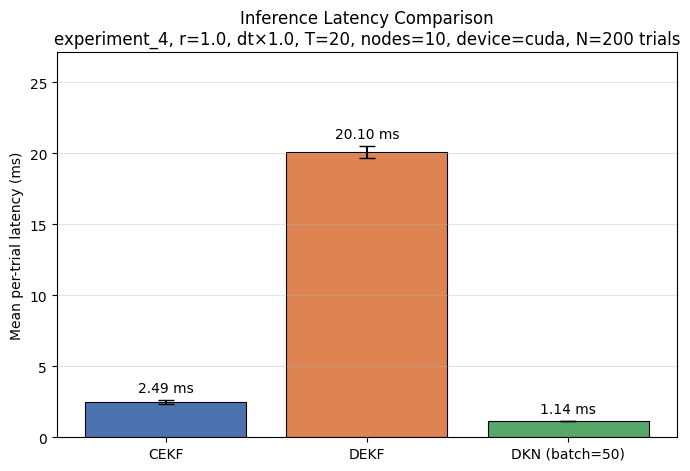

,mean_ms,std_ms,median_ms
CEKF,2.490214,0.143868,2.445964
DEKF,20.095283,0.448810,19.909175
DKN (batch=50),1.141693,0.023823,1.133130


In [ ]:
import time
from torch_geometric.data import Batch

# ── Config ────────────────────────────────────────────────────────────────────
LATENCY_EXP_DIR    = REPO_ROOT / "models" / "kfir" / "experiment_4"
LATENCY_R          = 1.0
LATENCY_DT_RATIO   = 1.0
LATENCY_NUM_TRIALS = 200   # timing trials per filter
LATENCY_BATCH_SIZE = 50    # trials per DKN forward pass
LATENCY_WARMUP     = 5     # warm-up batches discarded before timing

# ── Load experiment config ────────────────────────────────────────────────────
lat_cfg        = load_experiment_config(LATENCY_EXP_DIR)
lat_state_dim  = lat_cfg["state_dimension"]
lat_x_init     = np.array(lat_cfg["x0"], dtype=float).reshape(lat_state_dim, 1)
lat_p0         = np.eye(lat_state_dim) * lat_cfg["p0_scale"]
lat_num_nodes  = lat_cfg["num_nodes"]
lat_time_delta = lat_cfg["time_delta"]
lat_q          = lat_cfg["process_noise_std"]
lat_T          = lat_cfg.get("test_time_steps", lat_cfg["train_time_steps"])

lat_node_positions = np.array(lat_cfg["node_positions"], dtype=float)
lat_h_system = DistanceAngleObservation(lat_node_positions)
lat_adj = create_distance_based_graph(
    lat_node_positions, k_neighbors=lat_cfg["k_neighbors"], seed=lat_cfg["graph_seed"]
)
lat_j_matrix = np.array(lat_adj, dtype=float, copy=True)
np.fill_diagonal(lat_j_matrix, 1.0)
lat_r_array  = LATENCY_R * np.ones(lat_num_nodes)
lat_f_system = ConstantVelocityModel(lat_time_delta * LATENCY_DT_RATIO)

# ── Load DKN ─────────────────────────────────────────────────────────────────
lat_dkn_path = LATENCY_EXP_DIR / "DKN" / f"r={LATENCY_R}_dtx{LATENCY_DT_RATIO}.pth"
if not lat_dkn_path.exists():
    raise FileNotFoundError(f"Missing DKN checkpoint: {lat_dkn_path}")

lat_dkn = GraphKalmanProcess(
    lat_f_system,
    signal_dim=lat_state_dim,
    edge_features_dim=1,
    node_kalman_dim=lat_state_dim ** 2,
    edge_kalman_dim=2,
    hidden_dim=lat_cfg["hidden_dim"],
    lr=lat_cfg["learning_rate"],
    r_array=LATENCY_R,
    learn_edge_kalman=lat_cfg["learn_edge_kalman"],
    x0_scale=lat_x_init,
)
lat_dkn.load_state_dict(torch.load(lat_dkn_path, map_location="cpu", weights_only=False))
lat_dkn.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lat_dkn = lat_dkn.to(device)
print(f"DKN device: {device}")

# ── Generate all trial data upfront ──────────────────────────────────────────
seed_everything(lat_cfg["seed"])
total_trials = LATENCY_NUM_TRIALS + LATENCY_WARMUP * LATENCY_BATCH_SIZE
lat_trials = []
for _ in range(total_trials):
    traj = generate_trajectory(lat_f_system, lat_x_init, lat_T, lat_q)
    meas = generate_measurements(lat_h_system, traj, LATENCY_R)
    lat_trials.append((traj, meas))

# Build PyG Data objects once (graph construction excluded from timing)
lat_data_list = [
    build_graph_data_for_dkn(lat_adj, lat_h_system, t, m) for t, m in lat_trials
]

def sync_cuda():
    if device.type == "cuda":
        torch.cuda.synchronize()

# ── Warm-up DKN (fill CUDA caches, JIT, etc.) ────────────────────────────────
for wi in range(LATENCY_WARMUP):
    warm_batch = Batch.from_data_list(
        lat_data_list[wi * LATENCY_BATCH_SIZE : (wi + 1) * LATENCY_BATCH_SIZE]
    ).to(device)
    with torch.no_grad():
        _ = lat_dkn(warm_batch)
sync_cuda()

timing_data   = lat_data_list[LATENCY_WARMUP * LATENCY_BATCH_SIZE:]
timing_trials = lat_trials[LATENCY_WARMUP * LATENCY_BATCH_SIZE:]

# ── Time CEKF ────────────────────────────────────────────────────────────────
cekf_times = []
for traj, meas in tqdm(timing_trials, desc="Timing CEKF"):
    t0 = time.perf_counter()
    _ = centralized_extended_kalman_filter(
        measurements=meas, f_system=lat_f_system, h_system=lat_h_system,
        r_array=lat_r_array, q=lat_q, p0=lat_p0, x0=lat_x_init,
        time_steps=lat_T, node_num=lat_num_nodes,
    )
    cekf_times.append(time.perf_counter() - t0)

# ── Time DEKF ────────────────────────────────────────────────────────────────
dekf_times = []
for traj, meas in tqdm(timing_trials, desc="Timing DEKF"):
    t0 = time.perf_counter()
    _ = diffusion_extended_kalman_filter_parallel_edge(
        measurements=meas, f_system=lat_f_system, h_system=lat_h_system,
        r_array=lat_r_array, q=lat_q, p0=lat_p0, x0=lat_x_init,
        j_matrix=lat_j_matrix, time_steps=lat_T, node_num=lat_num_nodes,
    )
    dekf_times.append(time.perf_counter() - t0)

# ── Time DKN — batch inference, amortise cost per trial ──────────────────────
dkn_per_trial_ms = []
for bi in tqdm(range(0, len(timing_data), LATENCY_BATCH_SIZE), desc="Timing DKN (batch)"):
    chunk = timing_data[bi : bi + LATENCY_BATCH_SIZE]
    if not chunk:
        break
    batch = Batch.from_data_list(chunk).to(device)
    sync_cuda()
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = lat_dkn(batch)
    sync_cuda()
    dkn_per_trial_ms.extend([1e3 * (time.perf_counter() - t0) / len(chunk)] * len(chunk))

# ── Summary table ────────────────────────────────────────────────────────────
results_latency = {
    "CEKF":                             np.array(cekf_times) * 1e3,
    "DEKF":                             np.array(dekf_times) * 1e3,
    f"DKN (batch={LATENCY_BATCH_SIZE})": np.array(dkn_per_trial_ms),
}

latency_df = pd.DataFrame({
    label: {"mean_ms": v.mean(), "std_ms": v.std(), "median_ms": np.median(v)}
    for label, v in results_latency.items()
}).T
print(f"\nInference latency per trial (ms) — device: {device}")
print(latency_df.round(3).to_string())

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
labels = list(results_latency.keys())
means  = [results_latency[l].mean() for l in labels]
stds   = [results_latency[l].std()  for l in labels]
colors = ["#4C72B0", "#DD8452", "#55A868"]
bars = ax.bar(labels, means, yerr=stds, capsize=6, color=colors, edgecolor="black", linewidth=0.8)
for bar, m, s in zip(bars, means, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        m + s + max(means) * 0.015,
        f"{m:.2f} ms",
        ha="center", va="bottom", fontsize=10,
    )
ax.set_ylabel("Mean per-trial latency (ms)")
ax.set_title(
    f"Inference Latency Comparison\n"
    f"experiment_4, r={LATENCY_R}, dt×{LATENCY_DT_RATIO}, T={lat_T}, "
    f"nodes={lat_num_nodes}, device={device}, N={LATENCY_NUM_TRIALS} trials"
)
ax.grid(axis="y", alpha=0.35)
ax.set_ylim(0, max(means) * 1.35)

lat_plot_path = LATENCY_EXP_DIR / "plots" / (
    f"inference_latency_r={LATENCY_R}_dtx{LATENCY_DT_RATIO}_batch={LATENCY_BATCH_SIZE}.png"
)
fig.savefig(lat_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved: {lat_plot_path}")
plt.show()

latency_df
